In [89]:
import plotly.graph_objects as go
import numpy as np 
import json
from PetrizzeTheme import petrizze_template_go
from PetrizzeTheme import petrizze_template
import matplotlib.pyplot as plt

petrizze_template()
petrizze_template_go()
import base64

# May 4th Update

[-0.19999992847442627, -0.19900000095367432, -0.1979999542236328, -0.19700002670288086, -0.19599997997283936, -0.19499993324279785, -0.1929999589920044, -0.19200003147125244, -0.19099998474121094, -0.18999993801116943, -0.18900001049041748, -0.18799996376037598, -0.18699991703033447, -0.18599998950958252, -0.18499994277954102, -0.18400001525878906, -0.18299996852874756, -0.18199992179870605, -0.1809999942779541, -0.1799999475479126, -0.17900002002716064, -0.17799997329711914, -0.17699992656707764, -0.17599999904632568, -0.17499995231628418, -0.17400002479553223, -0.17299997806549072, -0.17199993133544922, -0.17100000381469727, -0.16999995708465576, -0.1690000295639038, -0.1679999828338623, -0.1669999361038208, -0.16600000858306885, -0.16499996185302734, -0.1640000343322754, -0.1629999876022339, -0.16199994087219238, -0.16100001335144043, -0.15999996662139893, -0.15899991989135742, -0.15799999237060547, -0.15699994564056396, -0.156000018119812, -0.1549999713897705, -0.153999924659729, -

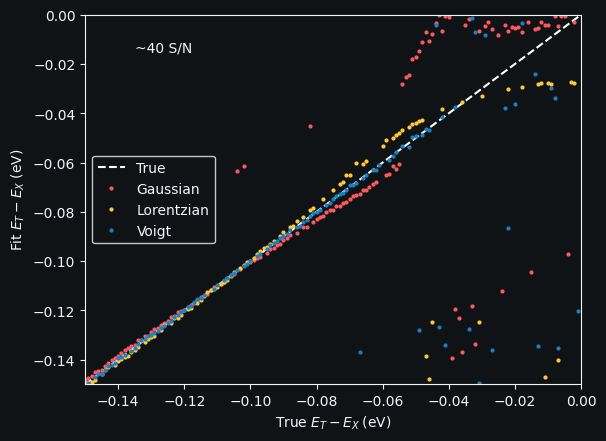

[-0.04400002956390381, -0.04100000858306885, -0.03399991989135742, -0.03100001811981201, -0.02799999713897705, -0.026999950408935547, -0.02499997615814209, -0.023000001907348633, -0.021000027656555176, -0.018999934196472168, -0.018000006675720215, -0.013000011444091797, -0.010999917984008789, -0.008000016212463379, -0.006999969482421875, -0.005999922752380371, -0.004999995231628418, -0.001999974250793457]
[-0.19999992847442627, -0.19900000095367432, -0.1979999542236328, -0.19599997997283936, -0.19499993324279785, -0.1940000057220459, -0.1929999589920044, -0.19200003147125244, -0.19099998474121094, -0.18999993801116943, -0.18900001049041748, -0.18799996376037598, -0.18599998950958252, -0.18499994277954102, -0.18400001525878906, -0.18299996852874756, -0.18199992179870605, -0.1809999942779541, -0.1799999475479126, -0.17900002002716064, -0.17799997329711914, -0.17699992656707764, -0.17599999904632568, -0.17499995231628418, -0.17400002479553223, -0.17299997806549072, -0.17199993133544922, -

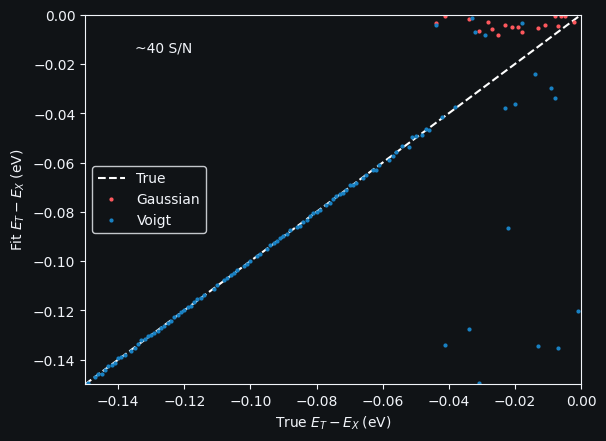

In [94]:
def do_it(filename):

    with open(f"Out\\{filename}.json") as f:
        fig_dict = json.load(f)

    fig = go.Figure(fig_dict)


    def to_native(arr):
        if arr is None:
            return None

        # Plotly typed-array encoding
        if isinstance(arr, dict) and set(arr.keys()) == {"dtype", "bdata"}:
            dtype = np.dtype(arr["dtype"]).newbyteorder("<")
            raw = base64.b64decode(arr["bdata"])
            return np.frombuffer(raw, dtype=dtype).tolist()

        # Normal arrays / lists
        if hasattr(arr, "tolist"):
            return arr.tolist()

        return list(arr)

    def extract_trace(trace):
        return {
            "x": to_native(trace.x),
            "y": to_native(trace.y),
            "name": trace.name,
        }



    subplot_traces = []
    for t in fig.data:
        if t.xaxis == 'x2' and t.yaxis == 'y2':
            if t.name.startswith('GAUSSIAN'):
                d = extract_trace(t)
                d['name'] = 'Gaussian'
                d['color'] = '#ff595e'
                subplot_traces.append(d)
            if t.name.startswith('LORENTZIAN'):
                d = extract_trace(t)
                d['name'] = 'Lorentzian'
                d['color'] = '#ffca3a'
                subplot_traces.append(d)
            if t.name.startswith('VOIGT'):
                d = extract_trace(t)
                d['name'] = 'Voigt'
                d['color'] = '#1982c4'
                subplot_traces.append(d)


    plt.plot([-0.15, 0], [-0.15, 0], color='#FFFFFF', linestyle='--', label='True')
    for trace in subplot_traces:
        x = trace['x']
        y = trace['y']
        print(x)
        name = trace['name']
        color = trace['color']
        plt.plot(x, y, label=name, color=color, linestyle='None', marker='o', markersize=2)

    plt.xlim([-0.15, 0])
    plt.ylim([-0.15, 0])
    plt.legend()
    ax = plt.gca()
    ax.text(
        0.1, 0.9,
        '~40 S/N',
        transform=ax.transAxes
    )

    xlabel = r'$\mathrm{True}\; E_T - E_X\;(\mathrm{eV})$'
    ylabel = r'$\mathrm{Fit}\; E_T - E_X\;(\mathrm{eV})$'

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.savefig(f'Out\\{filename}.png')
    plt.show()

do_it('260504')
do_it('260504-red-chi2-0.9-1.1')